In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Figure 1 Code

64
64
64
64
64
64
256
256


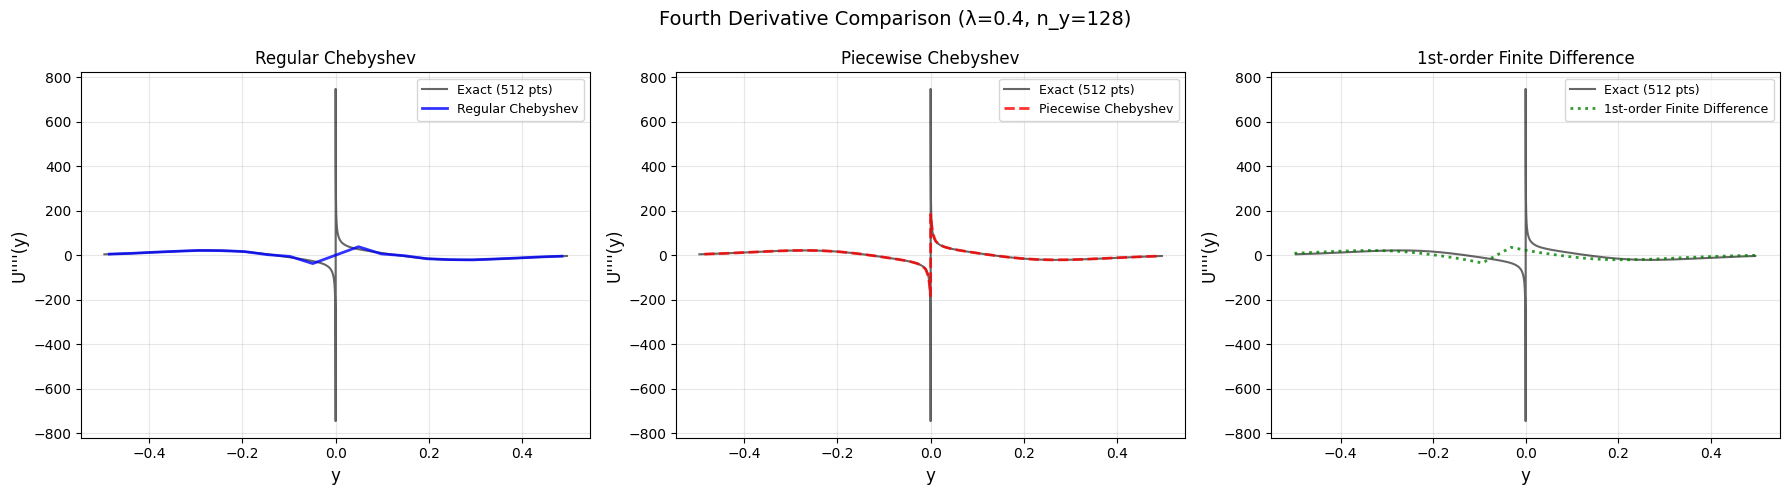

In [5]:
from util.exact_solution import construct_exact_solution
from util.chebyshev_diff import chebyshev_diff_matrix

def finite_diff_1st_order(y, u):
    """
    Compute first derivative using 1st-order accurate finite differences.
    
    The issue with repeated application: forward differences at the left boundary
    compound errors more than backward differences at the right boundary.
    This is because forward differences are less stable when applied repeatedly.
    """
    n = len(y)
    h = y[1] - y[0]  # Assuming uniform spacing
    du = np.zeros(n)
    
    # Forward difference at left boundary (only option): f'(x) ≈ (f(x+h) - f(x)) / h
    du[0] = (u[1] - u[0]) / h
    
    # Forward difference for interior points: f'(x) ≈ (f(x+h) - f(x)) / h
    for i in range(1, n-1):
        du[i] = (u[i+1] - u[i]) / h
    
    # Backward difference at right boundary: f'(x) ≈ (f(x) - f(x-h)) / h
    du[n-1] = (u[n-1] - u[n-2]) / h
    
    return du

n_y = 128
l = 0.4

# ===== Regular Chebyshev on [-2, 2] =====
D_chebyshev, y_chebyshev = chebyshev_diff_matrix(n_y+1, a=-2, b=2)
u_exact_chebyshev = construct_exact_solution(y_chebyshev, l=l)
# Compute fourth derivative: D^4
d4u_chebyshev = D_chebyshev @ D_chebyshev @ D_chebyshev @ D_chebyshev @ u_exact_chebyshev

# ===== Piecewise Chebyshev =====
n_segment = int(n_y/2)+1
D1, y1 = chebyshev_diff_matrix(n_segment, a=-2, b=0)
D2, y2 = chebyshev_diff_matrix(n_segment, a=0, b=2)

y_full = np.concatenate([np.flip(y1), np.flip(y2)])
# Compute exact solution on full grid
u_exact = construct_exact_solution(y_full, l=l)
u_exact_1 = np.flip(u_exact[:n_segment])
u_exact_2 = np.flip(u_exact[n_segment:])

# Compute fourth derivatives: D^4
D4U1 = D1 @ D1 @ D1 @ D1 @ u_exact_1
D4U2 = D2 @ D2 @ D2 @ D2 @ u_exact_2

# Combine for full domain
D4U_full = np.concatenate([np.flip(D4U1), np.flip(D4U2)])

# ===== 1st-order Finite Difference =====
# Use uniform grid for finite differences
y_fd = np.linspace(-2, 2, n_y+1)
u_exact_fd = construct_exact_solution(y_fd, l=l)
# Compute fourth derivative by applying first-order finite difference four times
du1 = finite_diff_1st_order(y_fd, u_exact_fd)
du2 = finite_diff_1st_order(y_fd, du1)
du3 = finite_diff_1st_order(y_fd, du2)
d4u_fd = finite_diff_1st_order(y_fd, du3)

# ===== Exact solution (Piecewise Chebyshev with 512 points) =====
n_y_exact = 512
n_segment_exact = int(n_y_exact/2)+1
D1_exact, y1_exact = chebyshev_diff_matrix(n_segment_exact, a=-2, b=0)
D2_exact, y2_exact = chebyshev_diff_matrix(n_segment_exact, a=0, b=2)

y_full_exact = np.concatenate([np.flip(y1_exact), np.flip(y2_exact)])
u_exact_exact = construct_exact_solution(y_full_exact, l=l)
U1_exact = np.flip(u_exact_exact[:n_segment_exact])
U2_exact = np.flip(u_exact_exact[n_segment_exact:])

D4U1_exact = D1_exact @ D1_exact @ D1_exact @ D1_exact @ U1_exact
D4U2_exact = D2_exact @ D2_exact @ D2_exact @ D2_exact @ U2_exact
D4U_full_exact = np.concatenate([np.flip(D4U1_exact), np.flip(D4U2_exact)])

# Filter exact solution to [-0.5, 0.5]
mask_exact = (y_full_exact >= -0.5) & (y_full_exact <= 0.5)
y_exact_filtered = y_full_exact[mask_exact]
D4U_exact_filtered = D4U_full_exact[mask_exact]

# ===== Filter data to [-0.5, 0.5] range =====
mask_chebyshev = (y_chebyshev >= -0.5) & (y_chebyshev <= 0.5)
y_chebyshev_filtered = y_chebyshev[mask_chebyshev]
d4u_chebyshev_filtered = d4u_chebyshev[mask_chebyshev]

mask_piecewise = (y_full >= -0.5) & (y_full <= 0.5)
y_full_filtered = y_full[mask_piecewise]
D4U_full_filtered = D4U_full[mask_piecewise]

mask_fd = (y_fd >= -0.5) & (y_fd <= 0.5)
y_fd_filtered = y_fd[mask_fd]
d4u_fd_filtered = d4u_fd[mask_fd]

# ===== Plot comparison on separate axes =====
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Fourth Derivative Comparison (λ={l}, n_y={n_y})', fontsize=14)

# Regular Chebyshev
axes[0].plot(y_exact_filtered, D4U_exact_filtered, 'k-', linewidth=1.5, alpha=0.6, label='Exact (512 pts)')
axes[0].plot(y_chebyshev_filtered, d4u_chebyshev_filtered, 'b-', linewidth=2, alpha=0.8, label='Regular Chebyshev')
axes[0].set_xlabel('y', fontsize=12)
axes[0].set_ylabel("U''''(y)", fontsize=12)
axes[0].set_title('Regular Chebyshev', fontsize=12)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Piecewise Chebyshev
axes[1].plot(y_exact_filtered, D4U_exact_filtered, 'k-', linewidth=1.5, alpha=0.6, label='Exact (512 pts)')
axes[1].plot(y_full_filtered, D4U_full_filtered, 'r--', linewidth=2, alpha=0.8, label='Piecewise Chebyshev')
axes[1].set_xlabel('y', fontsize=12)
axes[1].set_ylabel("U''''(y)", fontsize=12)
axes[1].set_title('Piecewise Chebyshev', fontsize=12)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# 1st-order Finite Difference
axes[2].plot(y_exact_filtered, D4U_exact_filtered, 'k-', linewidth=1.5, alpha=0.6, label='Exact (512 pts)')
axes[2].plot(y_fd_filtered, d4u_fd_filtered, 'g:', linewidth=2, alpha=0.8, label='1st-order Finite Difference')
axes[2].set_xlabel('y', fontsize=12)
axes[2].set_ylabel("U''''(y)", fontsize=12)
axes[2].set_title('1st-order Finite Difference', fontsize=12)
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



Processing λ = 0.4
Level 1/6 (n_y=2): Success=True, Residual norm=0.000000e+00
Level 2/6 (n_y=4): Success=False, Residual norm=4.214685e-08
Level 3/6 (n_y=8): Success=False, Residual norm=1.392587e-07
Level 4/6 (n_y=16): Success=False, Residual norm=5.114785e-07
Level 5/6 (n_y=32): Success=True, Residual norm=1.601628e-06
Level 6/6 (n_y=64): Success=True, Residual norm=7.831559e-06


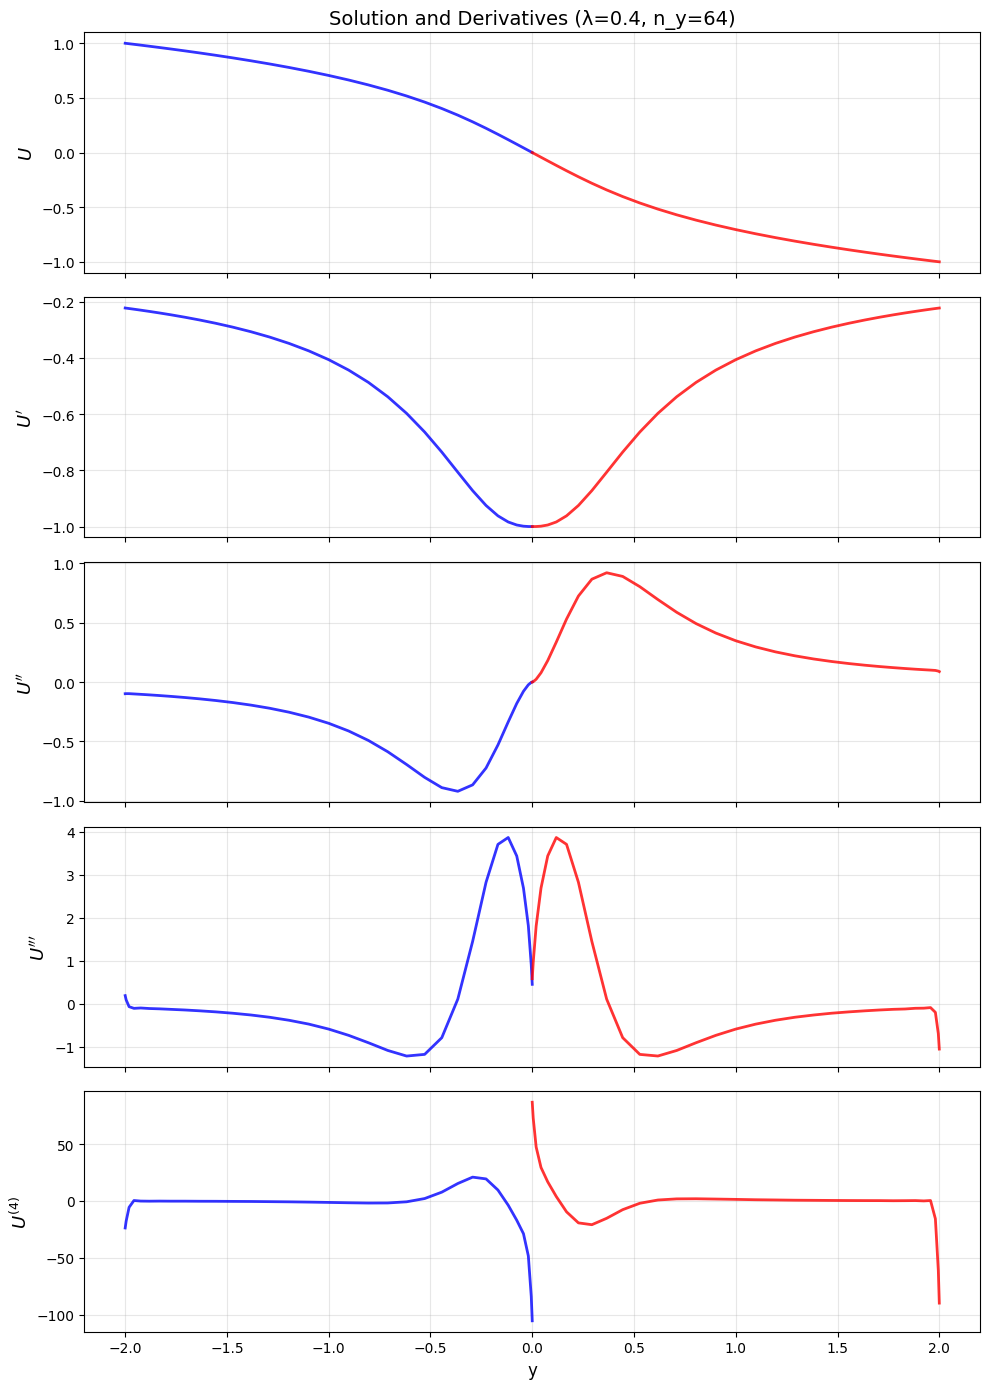

Completed λ = 0.4


Processing λ = 0.5
Level 1/6 (n_y=2): Success=True, Residual norm=0.000000e+00
Level 2/6 (n_y=4): Success=True, Residual norm=0.000000e+00
Level 3/6 (n_y=8): Success=False, Residual norm=6.916864e-08
Level 4/6 (n_y=16): Success=False, Residual norm=7.898956e-07
Level 5/6 (n_y=32): Success=True, Residual norm=1.835559e-06
Level 6/6 (n_y=64): Success=False, Residual norm=1.432000e-05


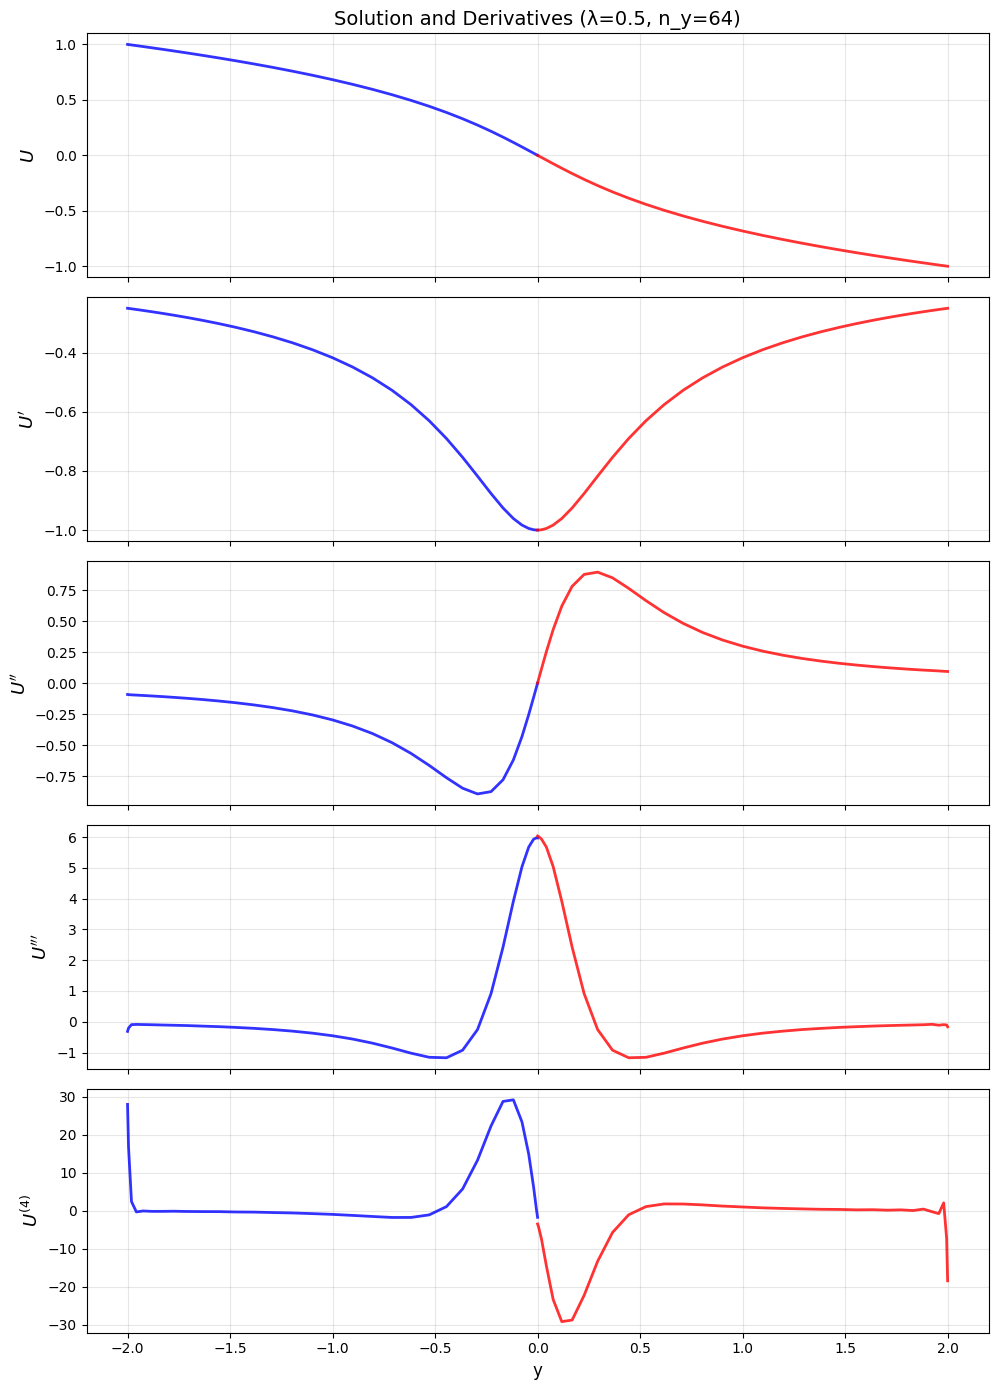

Completed λ = 0.5



In [6]:
from util.exact_solution import construct_exact_solution
from util.chebyshev_diff import chebyshev_diff_matrix
from chebyshev_piecewise_ad import fixed_l_inference_system

n_y = 64

# Process both lambda values
for l in [0.4, 0.5]:
    print(f"\n{'='*60}")
    print(f"Processing λ = {l}")
    print(f"{'='*60}")
    
    # Solve using piecewise Chebyshev with system-based optimization
    u_num, n_segment, (y1, D1, y2, D2) = fixed_l_inference_system(n_y, l, tol=1e-10, method='hybr')
    
    # Combine full domain
    y_full = np.concatenate([np.flip(y1), np.flip(y2)])
    
    # Extract solution on each segment (flip to match Chebyshev ordering)
    U1 = np.flip(u_num[:n_segment])
    U2 = np.flip(u_num[n_segment:])
    
    # Compute all derivatives
    derivatives = [u_num]  # Start with solution itself
    label_names = ["$U$", "$U'$", "$U''$", "$U'''$", "$U^{(4)}$"]
    
    U1_current = U1.copy()
    U2_current = U2.copy()
    
    for i in range(4):
        U1_current = D1 @ U1_current
        U2_current = D2 @ U2_current
        derivatives.append(np.concatenate([np.flip(U1_current), np.flip(U2_current)]))
    
    # Create figure with subplots for solution and derivatives
    fig, axs = plt.subplots(5, 1, figsize=(10, 14), sharex=True)
    
    for i, (ax, arr, name) in enumerate(zip(axs, derivatives, label_names)):
        # Plot each segment separately (flip back for plotting)
        ax.plot(y1, np.flip(arr[:n_segment]), 'b-', linewidth=2, alpha=0.8)
        ax.plot(y2, np.flip(arr[n_segment:]), 'r-', linewidth=2, alpha=0.8)
        ax.set_ylabel(name, fontsize=13)
        ax.grid(True, alpha=0.3)
        if i == 0:
            ax.set_title(f'Solution and Derivatives (λ={l}, n_y={n_y})', fontsize=14)
        if i == 4:
            ax.set_xlabel('y', fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Completed λ = {l}\n")
